Andrew Stephens

Machine Learning

Project Part 2  

Steve Geinitz

02 May 2026

Dataset to be utilized:


Explore the Automotive Trends Data | US EPA
U.S. Environmental Protection Agency - The EPA Automotive Trends Report: Greenhouse Gas
Emissions, Fuel Economy, and Technology since 1975

https://catalog.data.gov/dataset/the-epa-automotive-trends-report-greenhouse-gas-emissions-fuel-economy-and-technology-1975?from_hint=eyJxIjoiZnVlbCBlY29ub215In0%3D


This dataset is the EPA automotive trends report that encompasses Greenhouse gas emissions, fuel economy, and technology for vehicles that have been produced starting in 1975 until 2024. This data comes from the U.S. Environmental Protection Agency and their data collection efforts on every new light-duty vehicle model sold in the United States since 1975. The testing was
performed by the EPA at the National Vehicle and Fuel Emissions Laboratory in Ann Arbor, Michigan and also collected information directly from using the vehicle manufacturers official offsite EPA test results.

Hypothesis:

1) Is there a correlation between year produced and fuel efficiency?
2) Can we predict mpg based on the weight of a vehicle?
3) Does higher city mpg translate to higher mileage overall or does highway mpg translate to
higher mileage values overall

In [8]:
from IPython.core.display import HTML, Markdown, display
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

import numpy.random as npr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
import ipywidgets as widgets



For this dataset one observation consists of the following fields or columns:

*`Model Year` - the year the vehicle was produced

*`Regulatory Class` - the weight/frame class the vehicle falls under

*`Vehicle Type` - the vehicle model type (car or truck)

*`Production Share` - the percentage of the market share a specific vehicle type had during the year of production

*`Real World MPG` - the miles per gallon that was obtained during testing

*`Real World MPG_City` - the miles per gallon that was obtained during testing within a city setting

*`Real World MPG_Hwy` - the miles per gallon that was obtained during testing within a highway setting

*`Real World CO2` - the emissions output during testing

*`Real World CO2_City` - the emissions output during testing within a city setting

*`Real World CO2_Hwy` - the emissions output during testing within a highway setting

*`Weight(lbs)` - the dry weight of the vehicle or Gross Vehicle Weight Rating

*`Horsepower (HP)` - the vehicles power rating

*`Footprint (square foot)` - the projected area of the vehicle's body as seen from the front.



In [9]:
df = pd.read_csv('https://raw.githubusercontent.com/Drew0x/MLPRJ2/main/PRJ1ML.csv')
df.head()

,Model Year,Regulatory Class,Vehicle Type,Production Share,Real-World MPG,Real-World MPG_City,Real-World MPG_Hwy,Real-World CO2 (g/mi),Real-World CO2_City (g/mi),Real-World CO2_Hwy (g/mi),Weight (lbs),Horsepower (HP),Footprint (sq. ft.)
0,1975,All,All,1,13.05970,12.01552,14.61167,680.59612,739.73800,608.31160,4060.399,137.3346,-
1,1975,Car,All Car,0.806646,13.45483,12.31413,15.17266,660.63740,721.82935,585.84724,4057.494,136.1964,-
2,1975,Car,Sedan/Wagon,0.805645,13.45833,12.31742,15.17643,660.46603,721.63673,585.70185,4057.565,136.2256,-
3,1975,Truck,All Truck,0.193354,11.63431,10.91165,12.65900,763.86134,814.45060,702.03002,4072.518,142.0826,-
4,1975,Truck,Pickup,0.131322,11.91476,11.07827,13.12613,745.88139,802.20090,677.04643,4011.977,140.9365,-


Descriptive Statistics for each column:

In [10]:
df.describe()

,Model Year,Real-World MPG,Real-World MPG_City,Real-World MPG_Hwy,Real-World CO2 (g/mi),Real-World CO2_City (g/mi),Real-World CO2_Hwy (g/mi),Weight (lbs),Horsepower (HP)
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,1999.500000,20.369545,17.832833,23.294705,460.215577,521.383763,405.015245,4003.191732,186.184629
std,14.448942,4.835763,4.015557,5.667435,110.902354,112.203119,106.517854,553.209371,57.130647
min,1975.000000,10.530970,9.392720,10.813070,189.959100,209.466150,173.455880,2629.999000,87.813900
25%,1987.000000,17.133970,15.070850,19.426395,384.091835,446.959855,326.359520,3550.597250,140.326775
50%,1999.500000,19.724550,17.059200,22.723030,450.716185,521.156480,390.783365,3999.417500,180.595800
75%,2012.000000,23.141862,19.900662,27.195090,518.966480,589.953545,458.011485,4432.916250,225.453775
max,2024.000000,40.516790,37.428550,43.534150,844.017010,946.158200,821.998780,5484.824000,347.282700


To begin, we will be focusing on the first hypothesis question.

Hypothesis 1:

1) Is there a correlation between year produced and fuel efficiency?

This question investigates whether newer vehicles tend to be more fuel-efficient compared to older models, which is expected due to improvements in automotive technology over time.


**Exploratory Data Analysis for the first hypothesis question:**

Scatter plot of overall MPG amongst the regulatory classes across the 1975 - 2024 production years with correlation coefficient values.


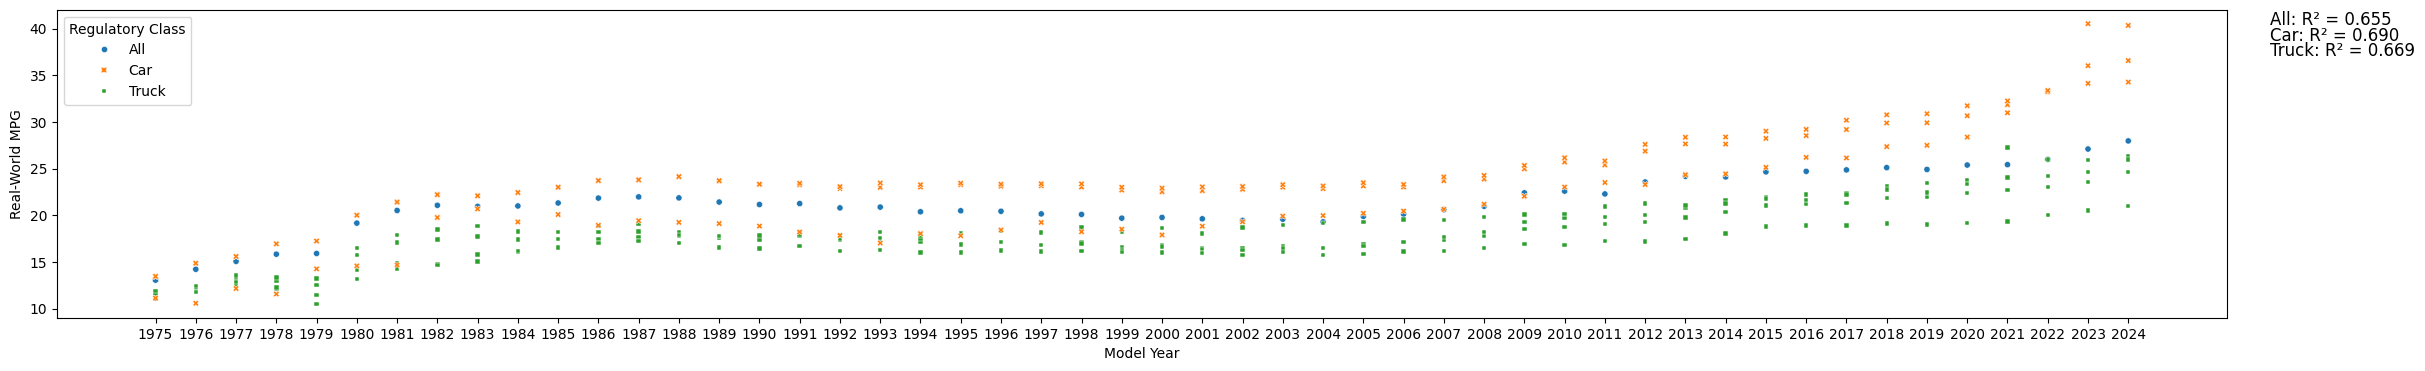

In [11]:
plt.figure(figsize=(28, 4))

sns.scatterplot(
    data=df,
    x='Model Year',
    y='Real-World MPG',
    hue='Regulatory Class',
    style='Regulatory Class',
    s=20
)

plt.xticks(df['Model Year'].unique())

classes = df['Regulatory Class'].unique()

ax = plt.gca()

y_pos = 0.95

for cls in classes:
    sub = df[df['Regulatory Class'] == cls]

    X = sub['Model Year'].values.reshape(-1, 1)
    y = sub['Real-World MPG'].values

    model = LinearRegression()
    model.fit(X, y)
    r2 = model.score(X, y)


    ax.text(
        1.02, y_pos,
        f"{cls}: R² = {r2:.3f}",
        transform=ax.transAxes,
        fontsize=12
    )
    y_pos -= 0.05

plt.show()


Scatter plot of City MPG amongst the regulatory classes across the 1975 - 2024 production years with correlation coefficient values.


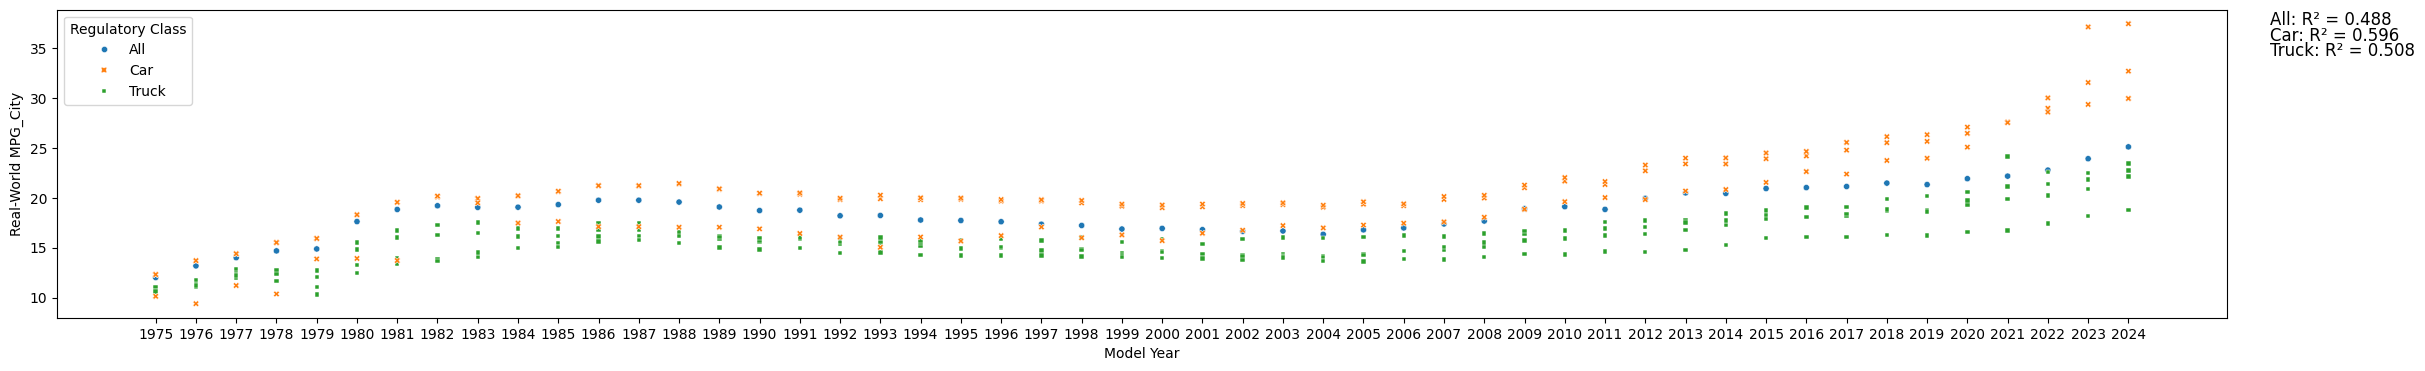

In [12]:
plt.figure(figsize=(28, 4))

sns.scatterplot(
    data=df,
    x='Model Year',
    y='Real-World MPG_City',
    hue='Regulatory Class',
    style='Regulatory Class',
    s=20
)

plt.xticks(df['Model Year'].unique())

classes = df['Regulatory Class'].unique()

ax = plt.gca()

y_pos = 0.95

for cls in classes:
    sub = df[df['Regulatory Class'] == cls]

    X = sub['Model Year'].values.reshape(-1, 1)
    y = sub['Real-World MPG_City'].values

    model = LinearRegression()
    model.fit(X, y)
    r2 = model.score(X, y)


    ax.text(
        1.02, y_pos,
        f"{cls}: R² = {r2:.3f}",
        transform=ax.transAxes,
        fontsize=12
    )
    y_pos -= 0.05

plt.show()


Scatter plot of Highway MPG amongst the regulatory classes across the 1975 - 2024 production years with correlation coefficient values.


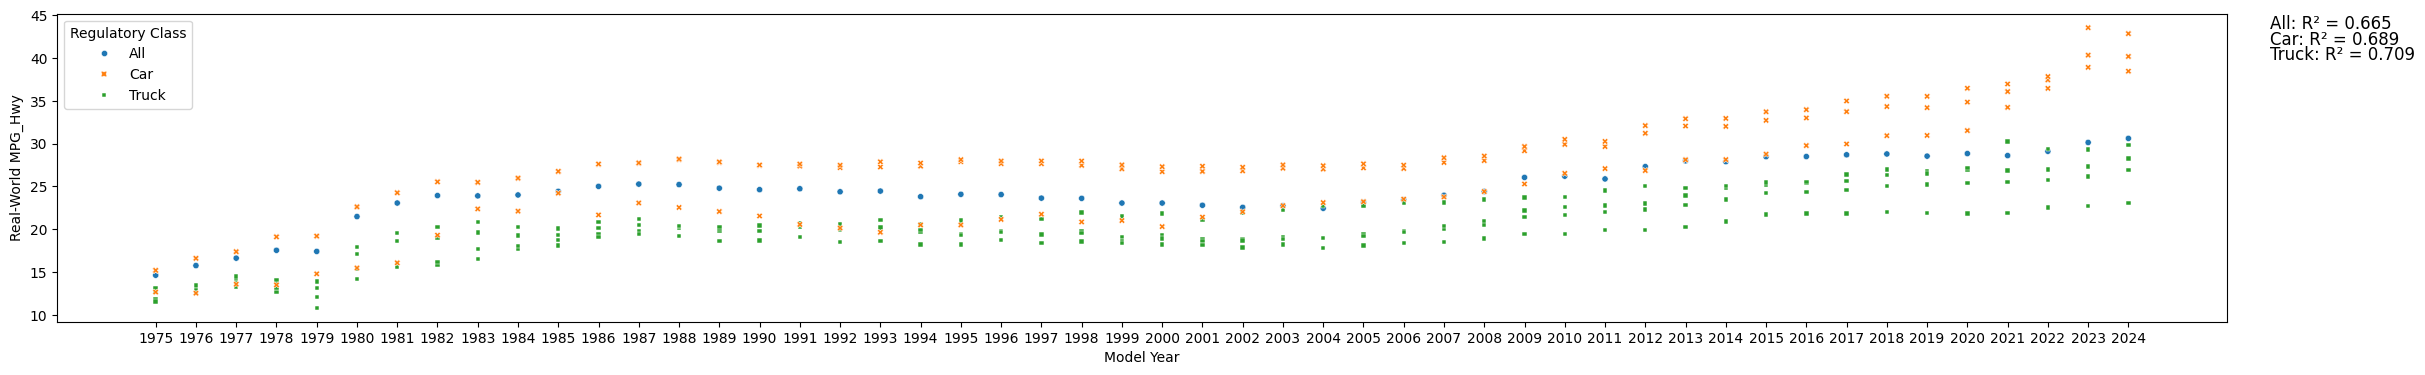

In [13]:
plt.figure(figsize=(28, 4))

sns.scatterplot(
    data=df,
    x='Model Year',
    y='Real-World MPG_Hwy',
    hue='Regulatory Class',
    style='Regulatory Class',
    s=20
)

plt.xticks(df['Model Year'].unique())

classes = df['Regulatory Class'].unique()



ax = plt.gca()

y_pos = 0.95

for cls in classes:
    sub = df[df['Regulatory Class'] == cls]

    X = sub['Model Year'].values.reshape(-1, 1)
    y = sub['Real-World MPG_Hwy'].values

    model = LinearRegression()
    model.fit(X, y)
    r2 = model.score(X, y)


    ax.text(
        1.02, y_pos,
        f"{cls}: R² = {r2:.3f}",
        transform=ax.transAxes,
        fontsize=12
    )
    y_pos -= 0.05

plt.show()


Based on the three MPG categories we can see that Highway MPG results in the highest R-squared value, with the highest value falling under the truck category. I will be focusing on utilizing the Highway MPG results across all regulatory classes since it yielded the highest correlation coefficient whilst also encompassing each of the regulatory class values.

Calculating the Intercept:

In [14]:
import statsmodels.api as sm

X = df[['Real-World MPG_Hwy']]
X = sm.add_constant(X)
y = df['Model Year']

sm_lm = sm.OLS(y, X).fit()
print(sm_lm.params)


const                 1958.885383
Real-World MPG_Hwy       1.743513
dtype: float64


In [15]:
lm = linear_model.LinearRegression()
lm.fit(df[['Real-World MPG_Hwy']], df['Model Year'])
print(lm.coef_, lm.intercept_)

[1.74351284] 1958.8853833816243


Scatterplot:

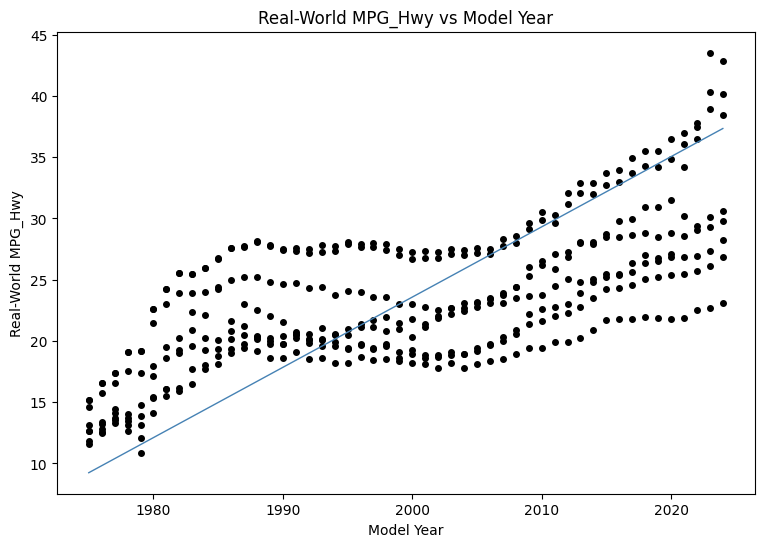

In [16]:
def plot_hypothesisone(slope, intercept):
    fig, ax = plt.subplots(figsize=(9, 6))
    x1 = np.linspace(df['Model Year'].min(), df['Model Year'].max(), 400)
    y1 = (x1 - intercept) / slope
    ax.plot(df['Model Year'], df['Real-World MPG_Hwy'], 'ko', markersize=4)

    ax.plot(x1, y1, '-', color='steelblue', linewidth=1)


    plt.xlabel("Model Year")
    plt.ylabel("Real-World MPG_Hwy")
    plt.title("Real-World MPG_Hwy vs Model Year")

    plt.show()

plot_hypothesisone(lm.coef_, lm.intercept_)

With Residuals:

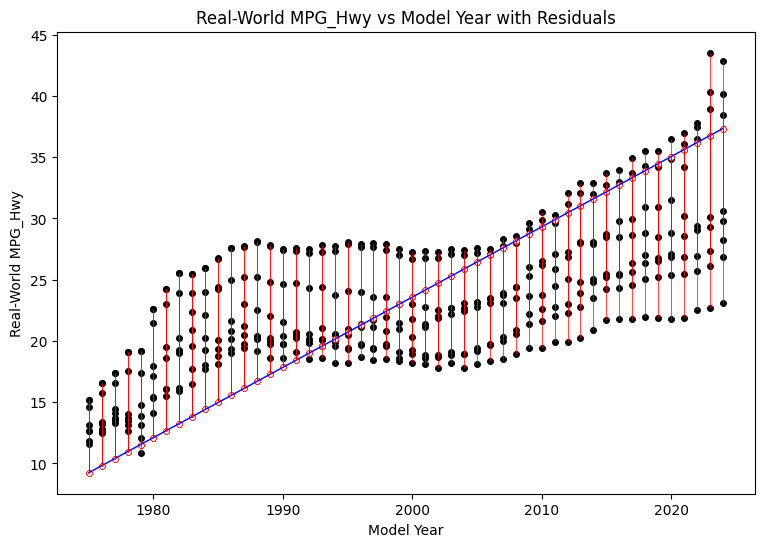

In [17]:
def plot_Resid(slope, intercept):
    fig, ax = plt.subplots(figsize=(9, 6))
    x_vals = df['Model Year']
    predict = (x_vals - intercept) / slope
    resid = df['Real-World MPG_Hwy'] - predict

    x1 = np.linspace(df['Model Year'].min(), df['Model Year'].max(), 400)
    y1 = (x1 - intercept) / slope

    ax.plot(df['Model Year'], df['Real-World MPG_Hwy'], 'ko', markersize=4)

    ax.plot(x_vals, predict, 'o',
            markersize=4,
            markeredgecolor='r',
            markeredgewidth=0.4,
            markerfacecolor='white')

    ax.plot(x1, y1, '-', color='blue', linewidth=1)

    ax.vlines(x_vals,
              df['Real-World MPG_Hwy'],
              predict,
              color='r', linewidth=0.5)

    plt.xlabel("Model Year")
    plt.ylabel("Real-World MPG_Hwy")
    plt.title("Real-World MPG_Hwy vs Model Year with Residuals")

    plt.show()

plot_Resid(lm.coef_, lm.intercept_)

Plotting the Least Squares Regression Line

<Axes: xlabel='Model Year', ylabel='Real-World MPG_Hwy'>

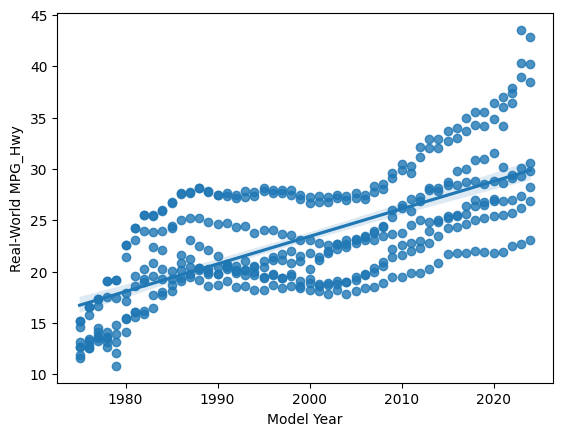

In [18]:
sns.regplot(x='Model Year', y='Real-World MPG_Hwy', data=df)

Printing the confidence intervals for the model coefficients

In [19]:
sub = df[df['Regulatory Class'] == cls]

X = sm.add_constant(sub['Model Year'])
y = sub['Real-World MPG_Hwy']

sm_lm = sm.OLS(y, X).fit()
r2 = sm_lm.rsquared

sm_lm.conf_int(alpha=0.05)

,0,1
const,-464.266519,-384.350079
Model Year,0.202405,0.242372


In [20]:
np.diff(df.shape)

array([-387])

In [21]:
# print the p-values for the model coefficients
sm_lm.pvalues

,0
const,4.232769e-52
Model Year,6.349613e-55


The P values within the dataset will reveal whether there is a correlation between the two categories within the dataset and aids in determining whether we should accept the null or alternative hypothesis. Which in this case since both values are small we can safely reject the null hypothesis and accept the alternative.

R - squared value for the linear model

In [22]:
sm_lm.rsquared

np.float64(0.7086587567116582)

In [23]:
sm_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     Real-World MPG_Hwy   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     481.6
Date:                Sat, 02 May 2026   Prob (F-statistic):           6.35e-55
Time:                        15:41:16   Log-Likelihood:                -428.11
No. Observations:                 200   AIC:                             860.2
Df Residuals:                     198   BIC:                             866.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -424.3083     20.263    -20.940      0.000    -464.267    -384.350
Model Year     0.2224      0.010     21.946      0.000       0.202       0.242
==============================================================================
Omnibus:                       27.203   Durbin-Watson:                   1.545
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                7.714
Skew:                          -0.079   Prob(JB):                       0.0211
Kurtosis:                       2.051   Cond. No.                     2.77e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.77e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The summary statistics suggest that there is a moderate relationship between year of vehicle production and miles per gallon highway. This can be evidenced from the 0.7 correlation coefficient which reveals a positive moderate relationship between the two categories within the data set.

**Random Forest Model (Nonlinear Comparison)**

To explore whether a more complex relationship exists, a Random Forest Regressor was also trained. This model does not assume linearity and helps determine whether nonlinear patterns improve predictive performance.

The number of trees (n_estimators) was tuned from 1 to 100 to observe performance changes.

In [24]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
numeric_df = df.select_dtypes(include=numerics).copy()

#y = numeric_df['Real-World MPG_Hwy'].copy()
#X = numeric_df.drop(columns=['Real-World MPG_Hwy']).copy()


X = df[['Model Year']]
y = df['Real-World MPG_Hwy']
X.columns = X.columns.astype(str)



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)


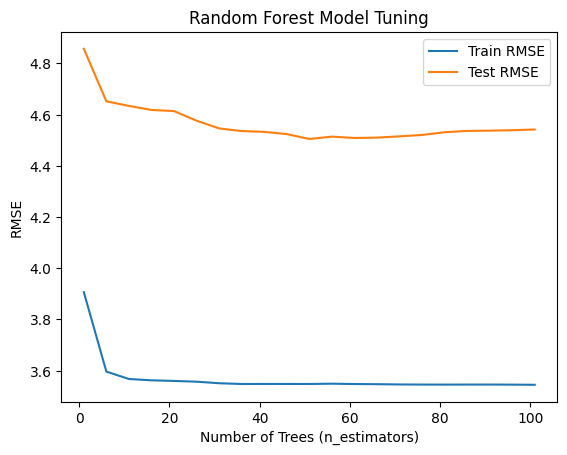

In [25]:
model_ls = LinearRegression()
num_features = X.shape[1]

rmse_values_ls = []
pred_rmse_values_ls = []

for i in range(1, num_features + 1):
    cols = X_train.columns[:i]

    model_ls.fit(X_train[cols], y_train)

    train_pred = model_ls.predict(X_train[cols])
    test_pred = model_ls.predict(X_test[cols])

    train_rmse = np.sqrt(np.mean((y_train - train_pred) ** 2))
    test_rmse = np.sqrt(np.mean((y_test - test_pred) ** 2))

    rmse_values_ls.append(train_rmse)
    pred_rmse_values_ls.append(test_rmse)

rmse_values_rf = []
pred_rmse_values_rf = []

poss_num_estimators = list(range(1, 102, 5))

for n in poss_num_estimators:
    model_rf = RandomForestRegressor(
        n_estimators=n,
        min_samples_leaf=1,
        random_state=2,
        n_jobs=-1
    )

    model_rf.fit(X_train, y_train)

    train_pred = model_rf.predict(X_train)
    test_pred = model_rf.predict(X_test)

    train_rmse = np.sqrt(np.mean((y_train - train_pred) ** 2))
    test_rmse = np.sqrt(np.mean((y_test - test_pred) ** 2))

    rmse_values_rf.append(train_rmse)
    pred_rmse_values_rf.append(test_rmse)

plt.plot(poss_num_estimators, rmse_values_rf, label='Train RMSE')
plt.plot(poss_num_estimators, pred_rmse_values_rf, label='Test RMSE')

plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('RMSE')
plt.title('Random Forest Model Tuning')
plt.legend()
plt.show()

The number of trees (n_estimators) was tuned from 1 to 100 to observe performance changes. The model stabilized at approximately 50 trees, beyond which additional trees yielded diminishing returns. However, a gap between training RMSE (3.55) and test RMSE (4.50) suggests the model is overfitting, indicating that Model Year alone is not a sufficiently strong predictor of highway fuel efficiency

In [26]:
model = LinearRegression()
model.fit(X, y)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.268241580972389
Intercept: -513.0543365292917


The linear regression model indicates a positive relationship between Model Year and highway fuel efficiency. The estimated coefficient of 0.268 suggests that, on average, each additional model year is associated with an increase of approximately 0.27 MPG. This implies that newer vehicles tend to be slightly more fuel-efficient than older vehicles, likely due to advancements in automotive technology over time.

While the relationship is positive, the magnitude of the effect is relatively small, suggesting that Model Year alone is not a strong predictor of fuel efficiency. Other vehicle characteristics, such as weight and hmoreorsepower, are likely to play a more significant role in determining MPG.

The intercept of -513.05 is not directly interpretable in a real-world context, as a Model Year of zero falls outside the observed data range.

Hypothesis:

1) Is there a correlation between year produced and fuel efficiency?

Null hypothesis: There is no relationship between Year Produced and Miles per gallon (and thus equals zero)


Alternative hypothesis: There is a relationship between the vehicle's Year Produced and Miles per gallon (and thus is not equal to zero)

In this instance we will be rejectiving the Null Hypothesis in favor of the Alternative hypothesis.



**The conclusion for the first hypothesis:**


The analysis suggests that Model Year has a measurable relationship with fuel efficiency. The linear regression model provides evidence of a trend between production year and MPG, supporting the hypothesis that newer vehicles tend to be more fuel-efficient. However, we can also see that while there is a relationship between the two categories the random forest model revealed that the gap inbetween training and test RMSE suggests overfitting which indicates that Model Year alone is not a sufficiently strong predictor of highway fuel efficiency.

However, the strength of this relationship depends on the magnitude of the regression coefficient and the correlation value. If these values are small, the effect of Model Year alone may be limited, suggesting that other vehicle attributes (such as weight or horsepower) play a larger role in determining fuel efficiency.


Diving deeper into the summary statistics we can see that there is a moderate relationship between year of vehicle production and miles per gallon highway. This can be evidenced from the 0.7 correlation coefficient which reveals a positive moderate relationship between the two categories within the data set.

Additionally, we can determine that based on a confidence interval of 0.95, the p value concludes that we should reject the null hypothesis in favor of the alternative.

const	4.232769e-52
Model Year	6.349613e-55

In this case, since the p-values are both so small, we can safely reject the null hypothesis in favor of the alternative. Since we generally ignore the p-value for the intercept. Thus, only focusing only on the model parameter associated with Model Year, and seeing a p-value far less than 0.05, we can conclude that there is a relationship between the vehicle's model year and MPG during highway driving conditions.

Overall, while Model Year contributes to explaining fuel efficiency, it is likely only one of several influencing factors.

.










.






The next hypothesis question is:

2) Can we predict mpg based on the weight of a vehicle?

This question investigates whether the weight of vehicles tends to be a more predictive element of fuel-efficiency compared to other categories within the dataset, which is to be expected as seen in the conclusion of the last hypothesis question.


**Exploratory Data Analysis for the second hypothesis question**

The relationship between Vehicle Weight and Overall fuel economy

const           32.104349
Weight (lbs)    -0.002931
dtype: float64


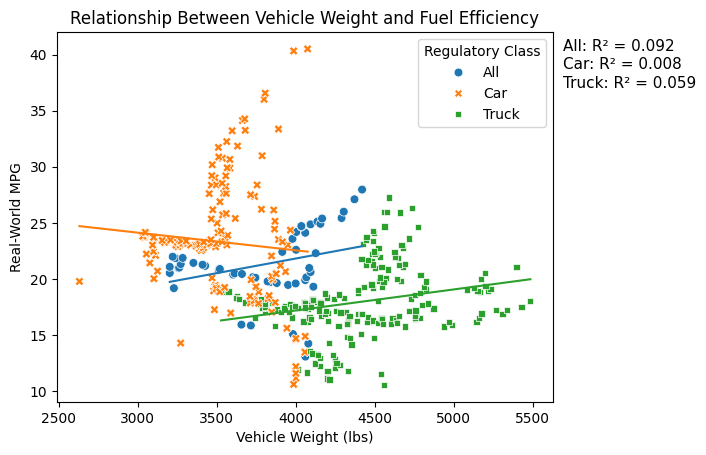

In [52]:
import statsmodels.api as sm

X = df[['Weight (lbs)']]
X = sm.add_constant(X)
y = df['Real-World MPG']

sm_lm = sm.OLS(y, X).fit()
print(sm_lm.params)

sns.scatterplot(
    data=df,
    x='Weight (lbs)',
    y='Real-World MPG',
    hue='Regulatory Class',
    style='Regulatory Class',
    s=40
)

ax = plt.gca()

classes = df['Regulatory Class'].unique()

y_pos = 0.95

for cls in classes:
    sub = df[df['Regulatory Class'] == cls]

    X = sub['Weight (lbs)'].values.reshape(-1, 1)
    y = sub['Real-World MPG'].values

    model = LinearRegression()
    model.fit(X, y)

    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)

    plt.plot(x_line, y_line)

    r2 = model.score(X, y)

    ax.text(
        1.02, y_pos,
        f"{cls}: R² = {r2:.3f}",
        transform=ax.transAxes,
        fontsize=11
    )
    y_pos -= 0.05

plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Real-World MPG")
plt.title("Relationship Between Vehicle Weight and Fuel Efficiency")
plt.show()

The relationship between Vehicle Weight and City MPG

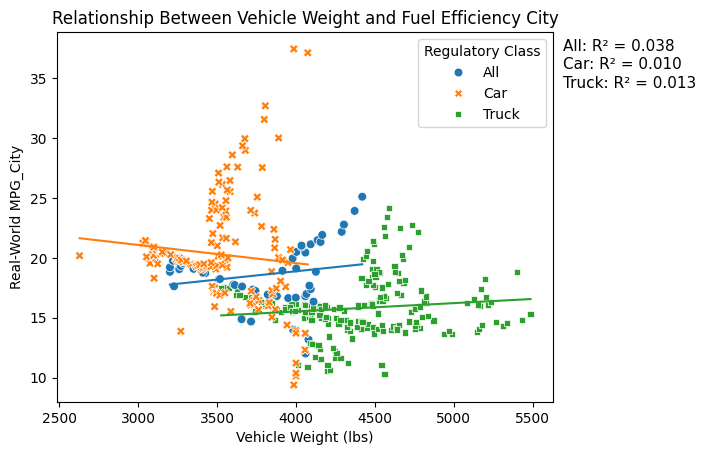

In [53]:
sns.scatterplot(
    data=df,
    x='Weight (lbs)',
    y='Real-World MPG_City',
    hue='Regulatory Class',
    style='Regulatory Class',
    s=40
)

ax = plt.gca()

classes = df['Regulatory Class'].unique()

y_pos = 0.95

for cls in classes:
    sub = df[df['Regulatory Class'] == cls]

    X = sub['Weight (lbs)'].values.reshape(-1, 1)
    y = sub['Real-World MPG_City'].values

    model = LinearRegression()
    model.fit(X, y)

    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)

    plt.plot(x_line, y_line)

    r2 = model.score(X, y)

    ax.text(
        1.02, y_pos,
        f"{cls}: R² = {r2:.3f}",
        transform=ax.transAxes,
        fontsize=11
    )
    y_pos -= 0.05

plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Real-World MPG_City")
plt.title("Relationship Between Vehicle Weight and Fuel Efficiency City")
plt.show()

The relationship between Vehicle Weight and Highway MPG

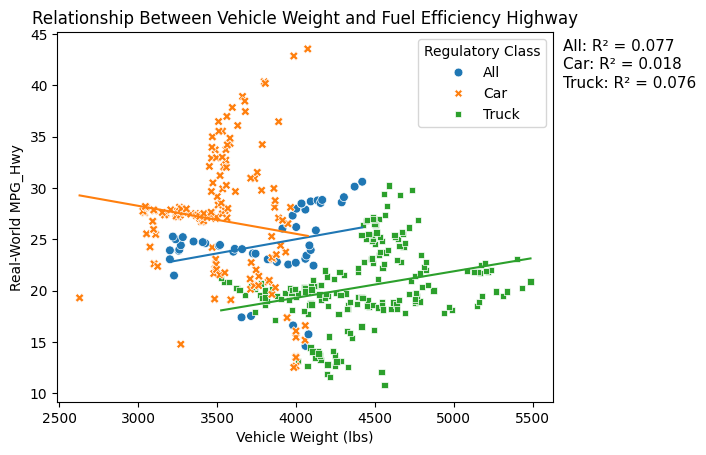

In [54]:
sns.scatterplot(
    data=df,
    x='Weight (lbs)',
    y='Real-World MPG_Hwy',
    hue='Regulatory Class',
    style='Regulatory Class',
    s=40
)

ax = plt.gca()

classes = df['Regulatory Class'].unique()

y_pos = 0.95

for cls in classes:
    sub = df[df['Regulatory Class'] == cls]

    X = sub['Weight (lbs)'].values.reshape(-1, 1)
    y = sub['Real-World MPG_Hwy'].values

    model = LinearRegression()
    model.fit(X, y)

    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)

    plt.plot(x_line, y_line)

    r2 = model.score(X, y)

    ax.text(
        1.02, y_pos,
        f"{cls}: R² = {r2:.3f}",
        transform=ax.transAxes,
        fontsize=11
    )
    y_pos -= 0.05

plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Real-World MPG_Hwy")
plt.title("Relationship Between Vehicle Weight and Fuel Efficiency Highway")
plt.show()

In [30]:
import statsmodels.api as sm

X = df[['Weight (lbs)']]
X = sm.add_constant(X)
y = df['Real-World MPG']

sm_lm = sm.OLS(y, X).fit()
print(sm_lm.params)


const           32.104349
Weight (lbs)    -0.002931
dtype: float64


In [31]:
lm = LinearRegression()
lm.fit(df[['Weight (lbs)']], df['Real-World MPG'])
print(lm.coef_, lm.intercept_)

[-0.00293136] 32.10434907790678


In [32]:
from sklearn.metrics import r2_score

y_pred = lm.predict(df[['Weight (lbs)']])
print(r2_score(df['Real-World MPG'], y_pred))

0.11245735362661435


Scatterplot:

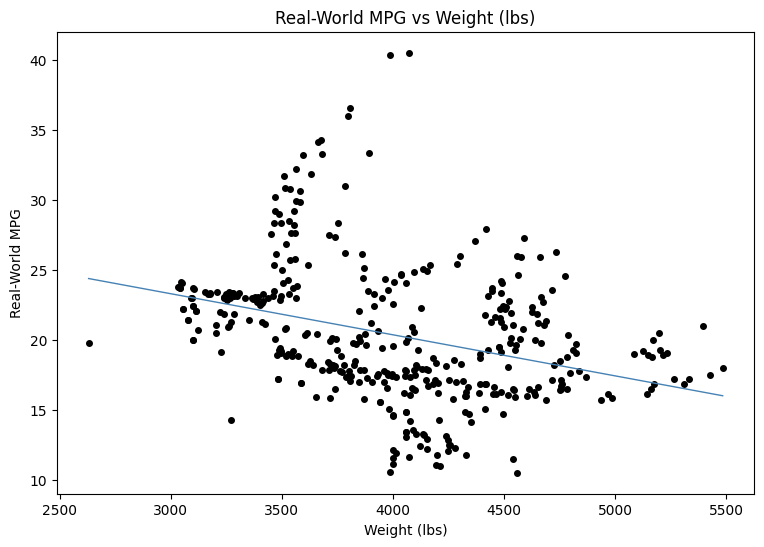

In [33]:
def plot_hypothesisone(slope, intercept):
    fig, ax = plt.subplots(figsize=(9, 6))
    x1 = np.linspace(df['Weight (lbs)'].min(), df['Weight (lbs)'].max(), 400)
    y1 = slope * x1 + intercept
    ax.plot(df['Weight (lbs)'], df['Real-World MPG'], 'ko', markersize=4)

    ax.plot(x1, y1, '-', color='steelblue', linewidth=1)

    plt.xlabel("Weight (lbs)")
    plt.ylabel("Real-World MPG")
    plt.title("Real-World MPG vs Weight (lbs)")

    plt.show()

plot_hypothesisone(lm.coef_[0], lm.intercept_)

With Residuals:

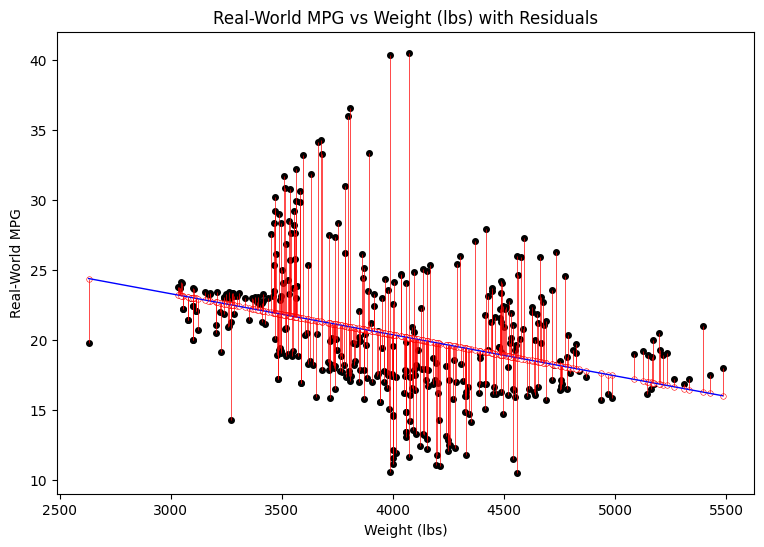

In [34]:
def plot_Resid(slope, intercept):
    fig, ax = plt.subplots(figsize=(9, 6))
    x_vals = df['Weight (lbs)']
    predict = slope * x_vals + intercept
    resid = df['Real-World MPG'] - predict

    x1 = np.linspace(df['Weight (lbs)'].min(), df['Weight (lbs)'].max(), 400)
    y1 = slope * x1 + intercept

    ax.plot(df['Weight (lbs)'], df['Real-World MPG'], 'ko', markersize=4)

    ax.plot(x_vals, predict, 'o',
            markersize=4,
            markeredgecolor='r',
            markeredgewidth=0.4,
            markerfacecolor='white')

    ax.plot(x1, y1, '-', color='blue', linewidth=1)

    ax.vlines(x_vals,
              df['Real-World MPG'],
              predict,
              color='r', linewidth=0.5)

    plt.xlabel("Weight (lbs)")
    plt.ylabel("Real-World MPG")
    plt.title("Real-World MPG vs Weight (lbs) with Residuals")

    plt.show()

plot_Resid(lm.coef_[0], lm.intercept_)

Plotting the Least Squares Regression Line

<Axes: xlabel='Weight (lbs)', ylabel='Real-World MPG'>

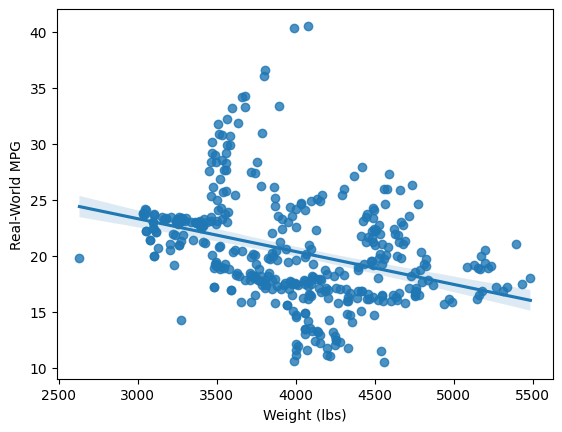

In [35]:
sns.regplot(x='Weight (lbs)', y='Real-World MPG', data=df)

We can see that the highest overall R-squared value is in the first scatterplot showing the relationship between vehicle weight and overall miles per gallon.

Printing the confidence intervals for the model coefficients

In [36]:
sub = df[df['Regulatory Class'] == cls]

X = sm.add_constant(sub['Weight (lbs)'])
y = sub['Real-World MPG']

sm_lm = sm.OLS(y, X).fit()
r2 = sm_lm.rsquared

sm_lm.conf_int(alpha=0.05)

,0,1
const,5.014086,14.320908
Weight (lbs),0.000826,0.002928


In [37]:
np.diff(df.shape)

array([-387])

In [38]:
sm_lm.rsquared

np.float64(0.05900152908542733)

P Value

In [39]:
sm_lm.pvalues

,0
const,0.000061
Weight (lbs),0.000529


Linear Regression Model:

In [40]:
X = df[['Horsepower (HP)']]
y = df['Real-World MPG']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lm = linear_model.LinearRegression()
lm.fit(X_train, y_train)

y_pred = lm.predict(X_test)
print("Coef:", lm.coef_[0])
print("Intercept:", lm.intercept_)
print("R² Score:", r2_score(y_test, y_pred))

X_const = sm.add_constant(X_train)
sm_lm = sm.OLS(y_train, X_const).fit()
print(sm_lm.summary())

Coef: 0.01915907459303739
Intercept: 16.78044744636206
R² Score: 0.15639352381200133
                            OLS Regression Results                            
Dep. Variable:         Real-World MPG   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     17.96
Date:                Sat, 02 May 2026   Prob (F-statistic):           2.96e-05
Time:                        15:41:22   Log-Likelihood:                -944.89
No. Observations:                 320   AIC:                             1894.
Df Residuals:                     318   BIC:                             1901.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Hypothesis Question #2:

Can we predict mpg based on the weight of a vehicle?

Null Hypothesis: There is no linear relationship between vehicle weight and MPG (slope = 0).

Alternative Hypothesis: There is a linear relationship between vehicle weight and MPG (slope != 0).


**Conclusion for the 2nd Hypothesis:**

In this instance we will be accepting the Alternative Hypothesis and rejecting the Null Hypothesis. We have determined that there is a statistically significant relationship between the two categories since the P values are less than 0.05 assuming a 95% confidence interval.

0
const	0.000061
Weight (lbs)	0.000529

Since the p-value for Weight (lbs) is 0.000529, which is far less than
0.05, we have sufficient evidence to conclude that vehicle weight does
have a measurable effect on fuel efficiency. However, while there is a relationship it is not a strong one, as we can see the R squared value is only 0.15 in the linear regression model which suggests that weight only accounts for a small percentage of the variance within the Real World MPG.

Additionally, we can also see that the summary statistics only yielded an R-squared value of 0.059 which is also more representative of the data set. Furthermore,the value is lower than the test set R² of 0.156, making it the more representative measure of the overall relationship and further reiterates the central theme that vehicle weight contributes to predicting MPG, but a more complete model incorporating additional features would be needed for
more reliable predictions.

.
















.

The Final Hypothesis Question:

Does higher city mpg translate to higher mileage overall or does highway mpg translate to higher mileage values overall?

**Exploratory Data Analysis for the final hypothesis question**

Scatterplot of City MPG in relation to overall MPG:

In [41]:
sub = df[df['Regulatory Class'] == cls]

X = sm.add_constant(sub['Real-World MPG'])
y = sub['Real-World MPG_City']

sm_lm = sm.OLS(y, X).fit()
r2 = sm_lm.rsquared

sm_lm.conf_int(alpha=0.05)

,0,1
const,1.566542,2.387030
Real-World MPG,0.748191,0.793223


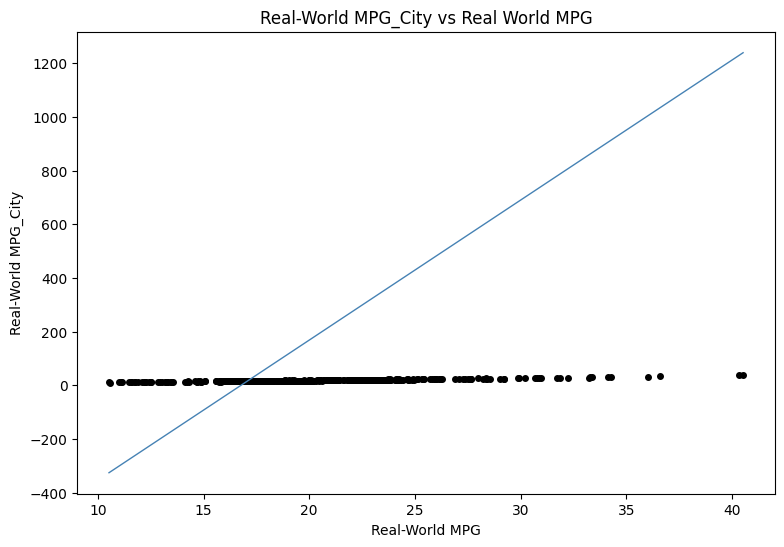

In [42]:
def plot_hypothesone(slope, intercept):
    fig, ax = plt.subplots(figsize=(9, 6))
    x1 = np.linspace(df['Real-World MPG'].min(), df['Real-World MPG'].max(), 400)
    y1 = (x1 - intercept) / slope
    ax.plot(df['Real-World MPG'], df['Real-World MPG_City'], 'ko', markersize=4)

    ax.plot(x1, y1, '-', color='steelblue', linewidth=1)


    plt.xlabel("Real-World MPG")
    plt.ylabel("Real-World MPG_City")
    plt.title("Real-World MPG_City vs Real World MPG")

    plt.show()

plot_hypothesone(lm.coef_, lm.intercept_)

With Residuals:

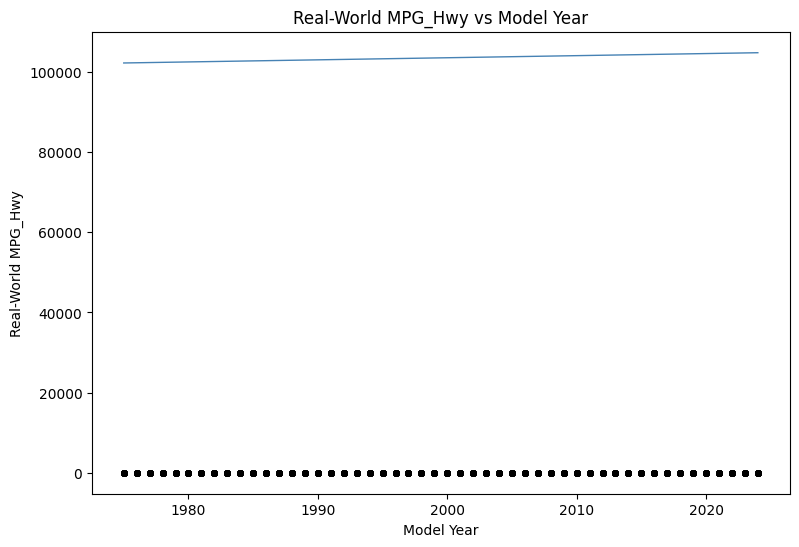

In [43]:
def plot_hypothone(slope, intercept):
    fig, ax = plt.subplots(figsize=(9, 6))
    x1 = np.linspace(df['Real-World MPG'].min(), df['Real-World MPG'].max(), 400)
    y1 = (x1 - intercept) / slope
    ax.plot(df['Real-World MPG'], df['Real-World MPG'], 'ko', markersize=4)

    ax.plot(x1, y1, '-', color='steelblue', linewidth=1)


    plt.xlabel("Real World MPG")
    plt.ylabel("Real-World MPG_City")
    plt.title("Real-World MPG_City vs Real-World MPG")

    plt.show()

plot_hypothone(lm.coef_, lm.intercept_)

Plotting Least Squares Regression Line For City MPG And Overall MPG:

<Axes: xlabel='Real-World MPG', ylabel='Real-World MPG_City'>

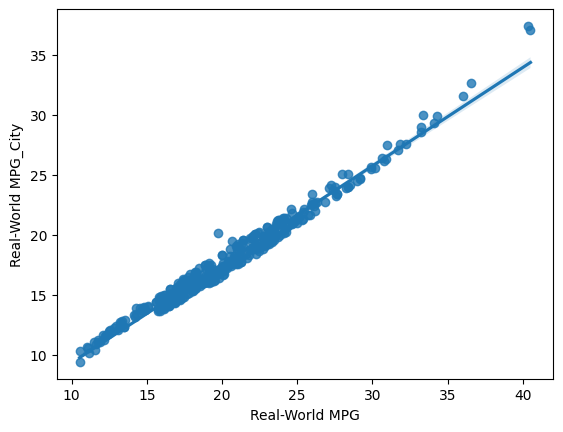

In [55]:
sns.regplot(x='Real-World MPG', y='Real-World MPG_City', data=df)

Scatterplot of Highway MPG in relation to overall MPG:

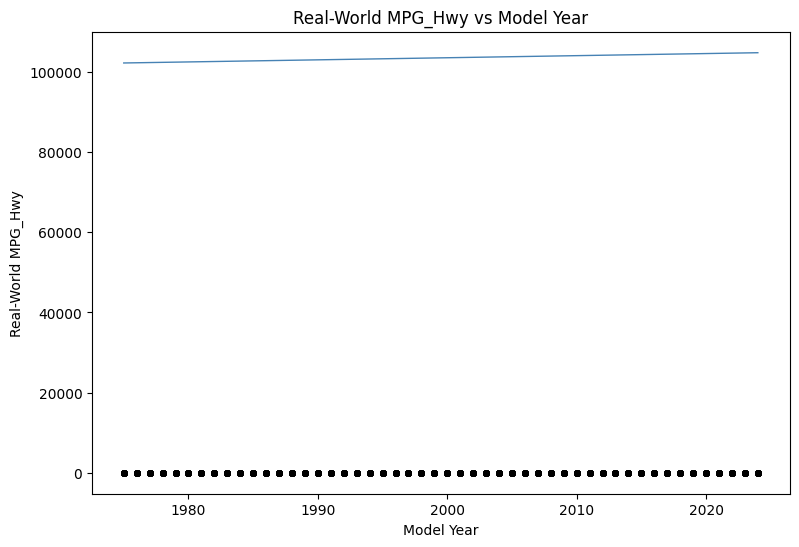

In [45]:
def plot_hypo(slope, intercept):
    fig, ax = plt.subplots(figsize=(9, 6))
    x1 = np.linspace(df['Model Year'].min(), df['Model Year'].max(), 400)
    y1 = (x1 - intercept) / slope
    ax.plot(df['Model Year'], df['Real-World MPG_Hwy'], 'ko', markersize=4)

    ax.plot(x1, y1, '-', color='steelblue', linewidth=1)


    plt.xlabel("Model Year")
    plt.ylabel("Real-World MPG_Hwy")
    plt.title("Real-World MPG_Hwy vs Model Year")

    plt.show()

plot_hypo(lm.coef_, lm.intercept_)

With Residuals:

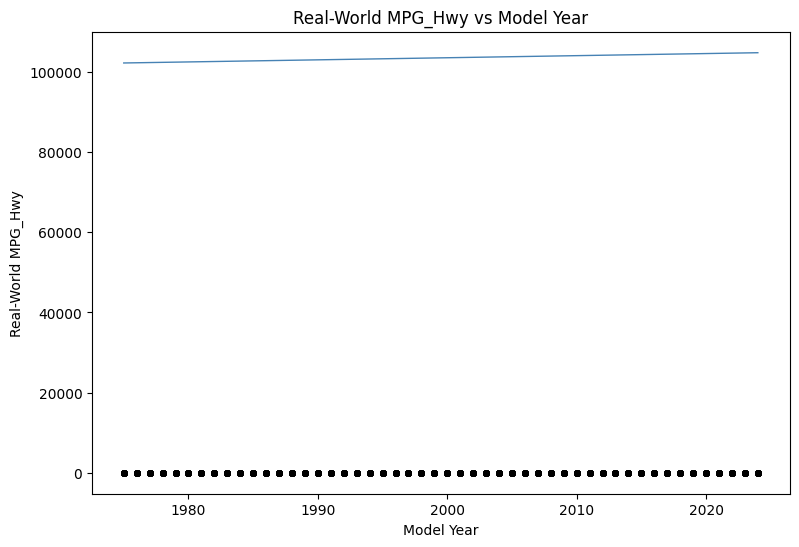

In [46]:
def plot_hyp(slope, intercept):
    fig, ax = plt.subplots(figsize=(9, 6))
    x1 = np.linspace(df['Model Year'].min(), df['Model Year'].max(), 400)
    y1 = (x1 - intercept) / slope
    ax.plot(df['Model Year'], df['Real-World MPG_Hwy'], 'ko', markersize=4)

    ax.plot(x1, y1, '-', color='steelblue', linewidth=1)


    plt.xlabel("Model Year")
    plt.ylabel("Real-World MPG_Hwy")
    plt.title("Real-World MPG_Hwy vs Model Year")

    plt.show()

plot_hyp(lm.coef_, lm.intercept_)

Plotting Least Squares Regression Line For Highway MPG And Overall MPG:

<Axes: xlabel='Real-World MPG', ylabel='Real-World MPG_Hwy'>

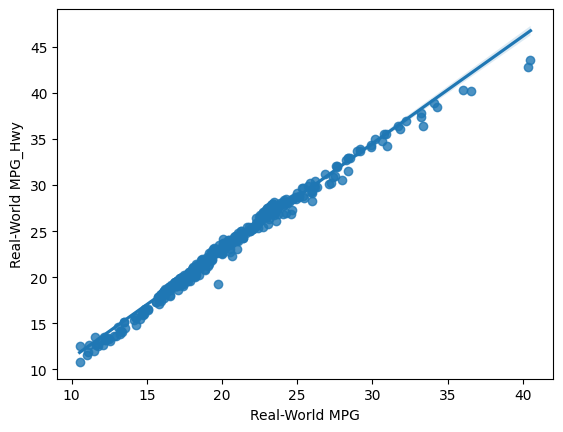

In [56]:
sns.regplot(x='Real-World MPG', y='Real-World MPG_Hwy', data=df)

Printing the confidence intervals

In [48]:
np.diff(df.shape)

array([-387])

In [49]:
sm_lm.pvalues

,0
const,7.026080e-18
Real-World MPG,1.256110e-138


**Gradient Boost Machine Learning Model:**

Hypothesis Question #3:

Does higher city mpg translate to higher mileage overall or does highway mpg translate to higher mileage values overall?

Null Hypothesis:

Alternative Hypothesis:

Conclusion for the Final Hypothesis Question:


.














.

References:

Class Assignments


Microsoft. (2024). Microsoft Copilot [Large language model].

https://copilot.microsoft.com


OpenAI. (2024). ChatGPT (Version 4) [Large language model].

https://chat.openai.com


U.S. Environmental Protection Agency, Office of Air and Radiation, Office of Transportation and Air Quality. (2019). The EPA Automotive Trends Report: Greenhouse Gas Emissions, Fuel Economy, and Technology since 1975 [Data set]. Data.gov. https://catalog.data.gov/dataset/the-epa-automotive-trends-report-greenhouse-gas-emissions-fuel-economy-and-technology-1975


